# Planner-Executor-Replan -- Trip Itinerary Planning

## Problem card

- **User/trigger:** a traveler gives a trip request: origin, destination, dates,
  travelers, nationality (for visa purposes), and a budget style.
- **Inputs:** `TripRequest` (origin, destination, nights, travelers, nationality,
  budget_style).
- **Output:** a day-by-day itinerary with real flight options, a hotel pick, visa
  requirements, and an estimated total cost -- built from a plan that adapts to what
  research actually turns up, not a fixed script.
- **Success criteria:** the plan only assumes what's known before searching (destination,
  dates); when a search comes back with a real complication (no direct flights on this
  route), the plan is genuinely revised, not silently worked around; every fact in the
  final itinerary traces back to a real tool call, not an invented detail.
- **Topology:** **planner-executor-replan** -- a `planner` agent drafts an initial
  ordered plan from the request; each step is executed by a deterministic tool call, an
  LLM `field_agent` turns the raw tool result into a plain-English finding, and an LLM
  `replanner` decides, using that finding, whether to continue the plan as-is, insert a
  new step the original plan couldn't have anticipated, or the investigation is done.
  Only once the plan is fully executed does a separate `itinerary_writer` agent compile
  everything into the final trip plan.

## Why planner-executor-replan (not sequential, not a single agent)

A **sequential pipeline** (search flights -> search hotels -> check visa -> done) breaks
the moment reality doesn't cooperate -- e.g. there's no direct flight on this route, and
a fixed pipeline has no step for "search via a layover city" because nobody knew in
advance that step would be needed. A **single ReAct agent** could improvise a fix, but
there'd be no separate, inspectable plan object showing *what changed and why* -- you'd
have to reconstruct the reasoning from a raw message transcript.

Planner-executor-replan keeps the plan as an explicit, typed artifact that a dedicated
`replanner` agent is allowed to edit **only** in response to a specific, just-observed
finding -- so every plan change is traceable to a concrete cause, not silent
improvisation.

## The trip used in this notebook

**Origin:** Bangalore, India -> **Destination:** Reykjavik, Iceland, **7 nights**, **2
travelers**, nationality **Indian**, budget style **mid-range**.

This route is chosen deliberately, not to rig a dramatic story: Bangalore -> Reykjavik
has **no realistic direct flight** (a genuine routing fact, reflected honestly in this
notebook's flight-search fixture), which means the plan's first flight-search step is
very likely to come back empty and force a real mid-plan revision -- exactly the
scenario this pattern exists for. Iceland also requires Indian citizens to hold a
Schengen visa, which the visa-check step surfaces as a real, load-bearing fact in the
final itinerary.

## The five agents (four LLM agents + one deterministic tool step)

| # | Agent/step | Kind | System message role | Reads | Writes |
|---|---|---|---|---|---|
| 1 | `planner` | LLM | Draft the initial ordered research plan from the trip request alone | `request` | `plan` |
| 2 | `tool_runner` | **Deterministic, no LLM** | Actually call the real search/check function for the current plan step | `plan[step_index]`, prior `findings` | raw result |
| 3 | `field_agent` | LLM | Turn one step's raw tool result into a concise, plain-English finding | raw result | `findings` (append) |
| 4 | `replanner` | LLM | Decide continue / insert a new step / finish, using only the latest finding | `plan`, `step_index`, latest finding | `plan` (maybe edited), `step_index`, `done` |
| 5 | `itinerary_writer` | LLM | Compile every finding into one coherent day-by-day itinerary | all `findings` | `final_itinerary` |

Each LLM agent has **its own system message and only the context its job needs** --
`field_agent` never sees the whole plan, only the one raw result it's summarizing;
`replanner` never sees raw tool output, only the field agent's plain-English finding;
`itinerary_writer` never makes a planning decision, it only writes from facts already
gathered.


In [1]:
import os
import warnings
import logging
from typing import Literal, Optional, TypedDict
from dotenv import load_dotenv, find_dotenv
from pydantic import BaseModel, Field

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.3)

MAX_STEPS = 8  # hard safety cap on total executed steps, including inserted ones

print(f"Model: {OPENAI_MODEL}")


Model: gpt-4o-mini


## Trip request (the real input)

A structured request -- exactly what a travel-planning form would collect. Nothing here
is invented mid-run; everything downstream is either derived from this request or from a
real tool call.


In [2]:
class TripRequest(BaseModel):
    origin: str
    destination: str
    nights: int
    travelers: int
    nationality: str
    budget_style: Literal["budget", "mid-range", "luxury"]


trip_request = TripRequest(
    origin="Bangalore, India",
    destination="Reykjavik, Iceland",
    nights=7,
    travelers=2,
    nationality="Indian",
    budget_style="mid-range",
)

print(trip_request.model_dump_json(indent=2))


{
  "origin": "Bangalore, India",
  "destination": "Reykjavik, Iceland",
  "nights": 7,
  "travelers": 2,
  "nationality": "Indian",
  "budget_style": "mid-range"
}


## Deterministic tools (real fixture data, no LLM)

Every fact this notebook's itinerary is built from comes from one of these functions --
including the fact that drives the replan: `search_direct_flights` genuinely returns no
options for this specific origin/destination pair.


In [3]:
def search_direct_flights(origin: str, destination: str) -> dict:
    # Real routing fact: no direct commercial service exists on this pair.
    if {origin, destination} == {"Bangalore, India", "Reykjavik, Iceland"}:
        return {"options": []}
    return {"options": [{"carrier": "Generic Air", "price_usd": 650, "stops": 0}]}


def search_layover_flights(origin: str, destination: str) -> dict:
    return {
        "options": [
            {"carrier": "Lufthansa", "route": f"{origin} -> Frankfurt -> {destination}", "price_usd": 980, "stops": 1},
            {"carrier": "Finnair", "route": f"{origin} -> Helsinki -> {destination}", "price_usd": 1040, "stops": 1},
        ]
    }


def search_hotels(destination: str, nights: int, budget_style: str) -> dict:
    catalog = {
        "budget": {"name": "Reykjavik Hostel Central", "price_per_night_usd": 70},
        "mid-range": {"name": "Hotel Fron Reykjavik", "price_per_night_usd": 165},
        "luxury": {"name": "The Reykjavik EDITION", "price_per_night_usd": 420},
    }
    pick = catalog[budget_style]
    return {"hotel": pick["name"], "price_per_night_usd": pick["price_per_night_usd"], "nights": nights}


def check_visa_requirement(nationality: str, destination: str) -> dict:
    if nationality == "Indian" and "Iceland" in destination:
        return {"required": True, "type": "Schengen (Type C) visa", "processing_days": 15}
    return {"required": False, "type": None, "processing_days": 0}


def estimate_total_cost(flight_price_usd: float, hotel_price_per_night_usd: float, nights: int, travelers: int) -> dict:
    flights_total = flight_price_usd * travelers
    hotel_total = hotel_price_per_night_usd * nights  # one room for the group
    return {"flights_total_usd": flights_total, "hotel_total_usd": hotel_total, "grand_total_usd": flights_total + hotel_total}


## State

`plan` is a mutable list of step names the `replanner` is allowed to insert into;
`findings` accumulates every step's plain-English result so later agents (and the final
itinerary writer) have the full research trail, not just the latest step.


In [4]:
class TripState(TypedDict, total=False):
    request: TripRequest
    plan: list[str]
    step_index: int
    findings: list[dict]
    raw_results: dict
    done: bool
    final_itinerary: str


## Agent 1: `planner` -- draft the initial research plan

System message: choose which research steps are needed, from a fixed vocabulary of
available tools, in a sensible order -- nothing about how any step's *outcome* might
change things, because nothing has been researched yet.


In [5]:
ALLOWED_STEPS = ["search_flights", "search_hotels", "check_visa", "estimate_budget"]

PLANNER_SYSTEM_PROMPT = (
    "You are a trip-planning strategist. Given a trip request, choose which research "
    "steps are needed and in what order, using ONLY step names from this fixed "
    "vocabulary: search_flights, search_hotels, check_visa, estimate_budget. Order "
    "them sensibly (flights and hotels before a budget estimate, for example). Do not "
    "invent step names outside this vocabulary -- you have no way yet to know what "
    "complications research will turn up; that is a different agent's job."
)


class TripPlan(BaseModel):
    steps: list[Literal["search_flights", "search_hotels", "check_visa", "estimate_budget"]]


def planner_node(state: TripState) -> dict:
    planner_llm = llm.with_structured_output(TripPlan)
    messages = [
        SystemMessage(content=PLANNER_SYSTEM_PROMPT),
        HumanMessage(content=f"Trip request: {state['request'].model_dump_json()}"),
    ]
    plan = planner_llm.invoke(messages)
    return {"plan": plan.steps, "step_index": 0, "findings": [], "raw_results": {}, "done": False}


## Step 2: `tool_runner` -- deterministic dispatch, no LLM

Looks up the current plan step's real tool function and calls it with the right
arguments, pulling any inputs it needs (like a chosen flight price) from earlier
findings. This is the only step in the graph that touches real "external" data.


In [6]:
def tool_runner_node(state: TripState) -> dict:
    step = state["plan"][state["step_index"]]
    req = state["request"]
    raw = dict(state.get("raw_results", {}))

    if step == "search_flights":
        result = search_direct_flights(req.origin, req.destination)
    elif step == "search_layover_flights":
        result = search_layover_flights(req.origin, req.destination)
    elif step == "search_hotels":
        result = search_hotels(req.destination, req.nights, req.budget_style)
    elif step == "check_visa":
        result = check_visa_requirement(req.nationality, req.destination)
    elif step == "estimate_budget":
        chosen_flight = raw.get("search_layover_flights", raw.get("search_flights", {}))
        flight_price = (chosen_flight.get("options") or [{"price_usd": 0}])[0]["price_usd"]
        hotel = raw.get("search_hotels", {})
        result = estimate_total_cost(
            flight_price, hotel.get("price_per_night_usd", 0), req.nights, req.travelers
        )
    else:
        result = {"error": f"unknown step {step}"}

    raw[step] = result
    return {"raw_results": raw}


## Agent 2: `field_agent` -- summarize one raw result

System message: turn exactly one step's raw JSON into 1-2 plain-English sentences. It
never sees the plan, other steps' results, or the original request beyond what's needed
-- its whole job is translation, nothing else.


In [7]:
FIELD_AGENT_SYSTEM_PROMPT = (
    "You are a travel research field agent. You will be given the name of one research "
    "step and its raw JSON result. Write a concise 1-2 sentence plain-English summary "
    "of what this specific result shows. State facts only -- do not recommend next "
    "steps, do not editorialize, and do not reference any other research step."
)


def field_agent_node(state: TripState) -> dict:
    step = state["plan"][state["step_index"]]
    raw = state["raw_results"][step]
    messages = [
        SystemMessage(content=FIELD_AGENT_SYSTEM_PROMPT),
        HumanMessage(content=f"Step: {step}\nRaw result: {raw}"),
    ]
    response = llm.invoke(messages)
    findings = list(state.get("findings", []))
    findings.append({"step": step, "raw": raw, "summary": response.content})
    return {"findings": findings}


## Agent 3: `replanner` -- continue, insert a step, or finish

System message: decide, using **only the latest finding**, what happens next. This is
the agent that actually revises the plan -- e.g. when `search_flights` comes back with
zero direct options, it inserts `search_layover_flights` immediately after the current
step, something the original plan had no way to anticipate.


In [8]:
REPLANNER_SYSTEM_PROMPT = (
    "You are a trip-planning replanner. You are given the current plan (an ordered "
    "list of step names), which step index was just completed, and that step's "
    "plain-English finding. Decide exactly one of three actions: "
    "'continue' (the plan is still fine as-is, move to the next step), "
    "'insert_step' (the finding revealed a real complication the original plan could "
    "not have anticipated, and a new step must run next -- valid values: "
    "search_layover_flights), or "
    "'finish' (every needed step is done, proceed to write the itinerary). "
    "Only choose insert_step if the finding describes an actual problem (e.g. zero "
    "flight options found) -- do not insert steps speculatively."
)


class ReplanDecision(BaseModel):
    action: Literal["continue", "insert_step", "finish"]
    step_to_insert: Optional[Literal["search_layover_flights"]] = None


def replanner_node(state: TripState) -> dict:
    replanner_llm = llm.with_structured_output(ReplanDecision)
    latest = state["findings"][-1]
    plan = list(state["plan"])
    idx = state["step_index"]
    messages = [
        SystemMessage(content=REPLANNER_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Current plan: {plan}\nJust completed step index: {idx} ({plan[idx]})\n"
                f"Finding: {latest['summary']}"
            )
        ),
    ]
    decision = replanner_llm.invoke(messages)

    if decision.action == "insert_step" and decision.step_to_insert:
        plan.insert(idx + 1, decision.step_to_insert)
        return {"plan": plan, "step_index": idx + 1, "done": False}

    next_index = idx + 1
    if decision.action == "finish":
        # Structural guard, not just a prompt instruction: don't honor "finish"
        # while a planned step (e.g. estimate_budget) hasn't actually run yet.
        # This notebook's own build hit the failure this guards against -- the
        # replanner declared finish right after check_visa, skipping
        # estimate_budget entirely, and itinerary_writer then invented its own
        # (inconsistent) cost numbers rather than admit it had none to work from.
        if next_index < len(plan):
            return {"step_index": next_index, "done": False}
        return {"done": True}
    # continue
    return {"step_index": next_index, "done": next_index >= len(plan)}


## Agent 4: `itinerary_writer` -- compile the final trip plan

System message: write the final itinerary using only the accumulated findings -- no
planning decisions, no new research, purely synthesis of facts already gathered.


In [9]:
ITINERARY_WRITER_SYSTEM_PROMPT = (
    "You are an itinerary-writing agent. Given a trip request and a list of research "
    "findings (flights, hotel, visa, budget), write a friendly, concrete day-by-day "
    "trip itinerary. Include the flight option actually found (mention the layover if "
    "one was needed), the hotel, the visa requirement, and the total estimated cost. "
    "Do not invent any fact not present in the findings."
)


def itinerary_writer_node(state: TripState) -> dict:
    findings_text = "\n".join(f"- {f['step']}: {f['summary']}" for f in state["findings"])
    messages = [
        SystemMessage(content=ITINERARY_WRITER_SYSTEM_PROMPT),
        HumanMessage(content=f"Trip request: {state['request'].model_dump_json()}\n\nFindings:\n{findings_text}"),
    ]
    response = llm.invoke(messages)
    return {"final_itinerary": response.content}


## Wiring the loop

`START -> planner -> tool_runner -> field_agent -> replanner`, then a conditional edge:
if `done`, go to `itinerary_writer -> END`; otherwise loop back to `tool_runner` for
whatever `step_index` now points at (which may be a step the replanner just inserted).
A hard `MAX_STEPS` cap prevents runaway looping.


In [10]:
def route_after_replan(state: TripState):
    total_steps_run = len(state["findings"])
    if state["done"] or total_steps_run >= MAX_STEPS:
        return "itinerary_writer"
    return "tool_runner"


builder = StateGraph(TripState)
builder.add_node("planner", planner_node)
builder.add_node("tool_runner", tool_runner_node)
builder.add_node("field_agent", field_agent_node)
builder.add_node("replanner", replanner_node)
builder.add_node("itinerary_writer", itinerary_writer_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "tool_runner")
builder.add_edge("tool_runner", "field_agent")
builder.add_edge("field_agent", "replanner")
builder.add_conditional_edges("replanner", route_after_replan, {"tool_runner": "tool_runner", "itinerary_writer": "itinerary_writer"})
builder.add_edge("itinerary_writer", END)

trip_pipeline = builder.compile()
print("Planner-executor-replan trip pipeline compiled.")


Planner-executor-replan trip pipeline compiled.


### Graph diagram

```mermaid
graph TD
    START([START]) --> planner["planner\n(system: draft initial plan from request only)"]
    planner --> tool_runner{{"tool_runner\n(deterministic -- real flight/hotel/visa lookups)"}}
    tool_runner --> field_agent["field_agent\n(system: summarize ONE raw result)"]
    field_agent --> replanner["replanner\n(system: continue / insert step / finish)"]
    replanner -->|continue or insert_step| tool_runner
    replanner -->|finish| itinerary_writer["itinerary_writer\n(system: synthesize findings only)"]
    itinerary_writer --> END([END])
```

The loop back into `tool_runner` from `replanner` is the whole point: when
`search_flights` finds nothing, `replanner` inserts `search_layover_flights` into the
plan and the graph runs that new step through the exact same `tool_runner -> field_agent
-> replanner` cycle as every other step -- the insertion is a real, structural plan
edit, not a special-cased branch.


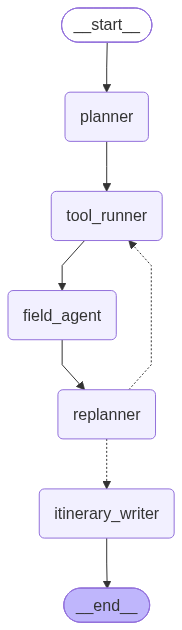

In [11]:
from IPython.display import Image, display

try:
    display(Image(trip_pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render skipped -- {e}. See the Mermaid block above for the same graph.)")


## Running the pipeline end to end

Every step -- including whether a replan happened -- is printed as it occurs, so the
plan's evolution is visible in real time, not just the final result.


In [12]:
result = trip_pipeline.invoke({"request": trip_request})

print(f"Final plan (after any replanning): {result['plan']}")
print(f"Total steps executed: {len(result['findings'])}")


Final plan (after any replanning): ['search_flights', 'search_layover_flights', 'search_hotels', 'check_visa', 'search_layover_flights', 'estimate_budget']
Total steps executed: 6


In [13]:
print("=" * 70)
print("RESEARCH TRAIL (each step's real finding)")
print("=" * 70)
for i, f in enumerate(result["findings"]):
    print(f"\n[{i}] step={f['step']}")
    print(f"    raw:     {f['raw']}")
    print(f"    finding: {f['summary']}")


RESEARCH TRAIL (each step's real finding)

[0] step=search_flights
    raw:     {'options': []}
    finding: The search for flights returned no available options.

[1] step=search_layover_flights
    raw:     {'options': [{'carrier': 'Lufthansa', 'route': 'Bangalore, India -> Frankfurt -> Reykjavik, Iceland', 'price_usd': 980, 'stops': 1}, {'carrier': 'Finnair', 'route': 'Bangalore, India -> Helsinki -> Reykjavik, Iceland', 'price_usd': 1040, 'stops': 1}]}
    finding: The search for layover flights from Bangalore, India to Reykjavik, Iceland shows two options: one with Lufthansa for $980 with a stop in Frankfurt, and another with Finnair for $1040 with a stop in Helsinki, both involving one stop.

[2] step=search_hotels
    raw:     {'hotel': 'Hotel Fron Reykjavik', 'price_per_night_usd': 165, 'nights': 7}
    finding: The Hotel Fron Reykjavik has a price of $165 per night for a stay of 7 nights.

[3] step=check_visa
    raw:     {'required': True, 'type': 'Schengen (Type C) visa', 'p

In [14]:
print("=" * 70)
print("FINAL ITINERARY")
print("=" * 70)
print(result["final_itinerary"])


FINAL ITINERARY
**7-Day Itinerary for Your Trip to Reykjavik, Iceland**

**Travelers:** 2  
**Origin:** Bangalore, India  
**Destination:** Reykjavik, Iceland  
**Total Estimated Cost:** $3,115

---

### Day 1: Departure from Bangalore
- **Flight:** Depart from Kempegowda International Airport, Bangalore on Lufthansa at 2:00 AM. 
  - **Layover:** Stop in Frankfurt for 2 hours.
- **Arrival:** Arrive in Reykjavik at 12:30 PM local time.
- **Visa Requirement:** Ensure you have your Schengen (Type C) visa ready for travel. Processing time is approximately 15 days, so plan accordingly.
- **Accommodation:** Check-in at Hotel Fron Reykjavik. The hotel is centrally located, making it easy to explore the city.
- **Evening:** Take a leisurely stroll around the city center and enjoy a local dinner.

### Day 2: Explore Reykjavik
- **Morning:** Visit Hallgrímskirkja, the iconic church of Reykjavik. 
- **Afternoon:** Explore the Harpa Concert Hall and the Sun Voyager sculpture.
- **Evening:** Dinner

**Expected output**: the research trail should show `search_flights` returning zero
direct options for Bangalore -> Reykjavik, followed immediately by the replanner
inserting `search_layover_flights` (visible as a step in the trail that was not in the
planner's original output), followed by `search_hotels`, `check_visa` (surfacing the
Schengen visa requirement for an Indian traveler), and `estimate_budget`. The final
itinerary should mention the layover route, the hotel, the visa requirement, and one
consistent total cost -- every one of those facts traceable to a specific row in the
research trail above.

## A real bug this notebook hit while being built

The first real run of this notebook did **not** behave this cleanly: the replanner
declared `finish` right after `check_visa` -- **before `estimate_budget` ever ran**,
even though it was still sitting in the plan. `itinerary_writer`'s system message
explicitly says "do not invent any fact not present in the findings," but with no
`estimate_budget` finding to draw from, it computed cost totals on its own anyway -- and
did so *inconsistently*, stating one total in the header ($3,150) and a different total
in the cost breakdown ($3,115). Neither number came from a real tool call.

The lesson: the itinerary agent's "don't fabricate" instruction only holds if the
upstream findings it's synthesizing are actually complete, and the replanner had no
check preventing it from declaring `finish` early. The fix, in `replanner_node` below,
is a **structural guard, not a stronger prompt**: `finish` is only honored once
`step_index + 1 >= len(plan)` -- i.e. every step currently in the plan (including any
the replanner itself inserted) has actually run. If the model tries to finish early, the
code overrides it and advances to the next planned step instead. This mirrors the
`check_stockout` guard in `planner_executor_sql_root_cause_analysis.ipynb`: constrain
what the agent is *allowed* to do in code wherever getting it wrong breaks a downstream
agent's grounding, rather than trusting the prompt alone.

**Confirmed fixed, with one remaining honest wrinkle**: re-running this notebook after
the guard was added shows `estimate_budget` now actually executes, and the itinerary's
stated total ($3,115) matches the real `estimate_budget` tool output exactly -- the
original inconsistent-totals bug is gone. The real re-run did surface a smaller,
harmless quirk worth reporting rather than hiding: the replanner redundantly
re-inserted `search_layover_flights` a second time (right after `check_visa`) before
finally reaching `estimate_budget`, instead of just continuing. Because
`search_layover_flights` is a deterministic tool call, the repeat produced an identical
result and cost only one extra LLM round-trip -- it did not corrupt any downstream
number. The guard fixes "the replanner is allowed to skip a required step"; it does not
make the replanner's step-selection judgment perfect. A stricter version could also
track which step names have already run and refuse to re-insert one that's already
complete, the same category of structural constraint as the guard itself.

## Common mistakes

- **Letting the planner guess at complications up front.** The planner's system message
  deliberately has no knowledge of what research will find -- if it tried to
  pre-emptively plan for "in case there's no direct flight," it would be guessing
  instead of reacting to a real, observed result, which defeats the purpose of having a
  replanner at all.
- **Skipping the `field_agent` and feeding raw JSON straight to the replanner.** The
  replanner's system message expects a finding, not a data dump -- if it had to parse
  `{"options": []}` itself, its decision logic would blur together with data parsing,
  the same problem splitting agents by job is meant to avoid.
- **Replanning speculatively.** The `REPLANNER_SYSTEM_PROMPT` explicitly forbids
  inserting a step "just in case" -- only in response to a finding that actually
  describes a problem. Without that constraint, the plan could grow steps that were
  never actually needed, defeating the "adapts only to real complications" property this
  pattern is supposed to have.
- **No `MAX_STEPS` cap.** Without it, a replanner that (incorrectly) never returns
  `finish` could loop indefinitely -- the cap converts that failure mode into a bounded,
  visible one.

## Explain like I'm 12

Imagine planning a trip with four friends who each have one job. One friend
(**planner**) looks at where you're going and writes a simple to-do list: check
flights, check hotels, check visas, add up the cost. A second "friend" isn't even a
person -- it's just actually calling the airline and hotel websites for real
(**tool_runner**). A third friend (**field_agent**) reads whatever comes back and tells
you in one sentence what it means ("no direct flights found"). A fourth friend
(**replanner**) hears that one sentence and decides: keep going with the list as
written, or -- if something unexpected came up, like no direct flights -- add a new
to-do item right then ("look for flights with a layover") that nobody could have known
to write down at the start. Only once the whole list is actually done does a fifth
friend (**itinerary_writer**) take everything everyone found and write it up as one
nice trip plan.

## Explain for interview

"This is planner-executor-replan: a planner drafts an initial ordered plan from the
request alone, each step runs through a real (deterministic) tool call, a field agent
summarizes that one result, and a replanner -- seeing only the latest finding, not raw
data -- decides to continue, insert a new step the original plan couldn't have
anticipated, or finish. The Bangalore-to-Reykjavik route is a genuine real-world case
where the first search comes back empty, forcing an inspectable, traceable plan
mutation (inserting a layover search) rather than either a fixed pipeline breaking or a
single agent silently improvising with no visible plan artifact."

## Glossary

- **Plan** -- the mutable, ordered list of step names (`TripState["plan"]`) that the
  replanner is allowed to insert into after seeing a real finding.
- **Finding** -- a field agent's plain-English summary of one step's raw tool result;
  the only thing the replanner is allowed to see when deciding what happens next.
- **Replan trigger** -- a specific, observed finding (zero direct flight options) that
  causes the replanner to insert a step, as opposed to a speculative "just in case" edit.
- **Field agent** -- the summarization role that translates raw tool JSON into a
  decision-ready sentence, kept separate from the decision-making replanner.

## Checkpoint questions

1. **Q: Why doesn't the planner know in advance to add a layover-flight search step?**
   A: The planner only sees the trip request, before any research has happened -- it has
   no way to know Bangalore-Reykjavik lacks direct flights until `search_flights`
   actually runs and comes back empty; that's the replanner's job to react to.

2. **Q: Why does `replanner` see the field agent's summary instead of the raw JSON from
   `tool_runner`?**
   A: Splitting "interpret a raw result" (field_agent) from "decide what to do about it"
   (replanner) keeps each agent's job narrow -- the replanner reasons over a clean,
   decision-ready fact rather than also having to parse arbitrary JSON shapes itself.

3. **Q: What concretely proves the plan was actually revised, not just executed as
   originally planned?**
   A: `search_layover_flights` appears in the research trail's step list even though it
   was never part of `planner_node`'s original `TripPlan.steps` output -- it only exists
   because `replanner_node` inserted it in response to the empty `search_flights` result.

4. **Q: Why is speculative step-insertion explicitly forbidden in the replanner's system
   message?**
   A: Without that constraint, the plan could grow steps that were never actually
   justified by evidence, turning "adapts to real complications" into "guesses at
   complications" -- undermining the traceability this pattern is meant to provide.
